# Simulator Example

In [27]:
import matplotlib.pyplot as plt

In [1]:
cost_failure = 1200
cost_component = 100
cost_inspection = 100
cost_replacement = 1000

In [2]:
eta = 30*24
beta = 3

expiration = 1.1*eta

In [3]:
mu = 7*24
sigma = 0.15*mu

theta = 12

In [4]:
inspection_threshold = 0.5
inspection_deviation = 0.05

### Simulate

We show an example of how to use the simulator implemented in the package `simmcm2d` to obtain samples. Do not forget to have the library in question installed in order to run the following.

In [5]:
from simmcm2d import sample_datasets, sample_datasets_conf, get_kpi

In [24]:
param = {
    "eta":eta,
    "beta":beta,
    "expiration":expiration,

    "mu":mu,
    "sigma":sigma,
    "theta":theta,
    "inspection_deviation":inspection_deviation,
    "inspection_threshold":inspection_threshold,
}

costs = {
    "replacement":cost_replacement,
    "inspection":cost_inspection,
    "component":cost_component,
    "failure":cost_failure
}

conf = {
    "param":param,
    "costs":costs,
    "n_systems":10,
    "date_first": "2010-01-01",
    "date_final": "2025-12-31",
    "id_0_component":0,
    "id_0_system":0
}

In [18]:
df = sample_datasets(param, costs, n_systems = 10,
                     date_first = "2010-01-01",
                     date_final = "2025-12-31 12:00",
                     id_0_component=0, id_0_system=0)

df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,10,10,2010-01-05,02:08:08,inspection,NaN,98.14,98.14,98.14,None,100,100
1,5,5,2010-01-06,11:24:48,inspection,NaN,131.41,131.41,131.41,None,100,100
2,2,2,2010-01-06,18:35:58,inspection,NaN,138.60,138.60,138.60,None,100,100
3,6,6,2010-01-07,02:40:40,inspection,NaN,146.68,146.68,146.68,None,100,100
4,3,3,2010-01-07,05:25:51,inspection,NaN,149.43,149.43,149.43,None,100,100


In [19]:
df.tail()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
11363,1,2220,2025-12-29,17:09:08,inspection,NaN,140201.15,217.13,217.13,None,100,507600
11364,5,2216,2025-12-30,14:29:11,failure,NaN,140222.49,441.75,131.52,None,1200,560100
11365,5,2216,2025-12-30,14:29:11,replacement,unused,140222.49,441.75,0.00,None,1100,561200
11366,3,2215,2025-12-30,16:43:36,inspection,NaN,140224.73,444.87,147.76,None,100,514900
11367,8,2221,2025-12-31,00:32:20,inspection,NaN,140232.54,204.90,204.90,None,100,523500


### Computing KPI

The library also exposes the following functionality responsible for computing the KPIs

In [20]:
KPI = get_kpi(df, costs=costs)

KPI

{'Average of failure per month': np.float64(7.692708333333333),
 'Average of failure per trimestre': np.float64(23.078125),
 'Average of failure per year': np.float64(92.3125),
 'Stability per month': np.float64(1.616334797084215),
 'Stability per trimestre': np.float64(2.6991602897644427),
 'Stability per year': np.float64(4.2968011357287645),
 'Average of replacement per month': np.float64(12.338541666666666),
 'Average of replacement per trimestre': np.float64(37.015625),
 'Average of replacement per year': np.float64(148.0625),
 'Preventive Effectiveness Ratio (PER)': np.float64(1.6039268788083954),
 'Précision du détecteur': 0.8,
 'Taux de détection (Rappel)': np.float64(0.29),
 'Average cost of one system': np.float64(511490.0),
 'Standard Deviation': np.float64(21442.141787714314)}

### Saving to Outputs Files

If the parameters implement the fields:
 * `output_data_filepath` - used to save the dataframe generated
 * `output_table_filepath` - used to save/reunite the parameters used
 
the speficied filepath are used to save the relevant data:

In [21]:
conf["output_data_filepath"] = "sample_system_dataset_1.csv"
conf["output_table_filepath"] = "sample_system_datatable.csv"

In [22]:
df = sample_datasets(**conf)

df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,3,3,2010-01-06,01:13:50,inspection,NaN,121.23,121.23,121.23,None,100,100
1,9,9,2010-01-06,03:49:10,inspection,NaN,123.82,123.82,123.82,None,100,100
2,1,1,2010-01-06,08:03:20,inspection,NaN,128.06,128.06,128.06,None,100,100
3,4,4,2010-01-07,03:38:19,inspection,NaN,147.64,147.64,147.64,None,100,100
4,10,10,2010-01-07,19:43:45,inspection,NaN,163.73,163.73,163.73,None,100,100


### Using Json Configuration

Alternative to the previous direct call, one can take advantage of using a `.json` configuration file as follows, by reading the configuration file and passng directly the parameters, or by using the specific function:

In [25]:
conf_filepath = "sample_system_dataset.json"

df = sample_datasets_conf(conf_filepath)
df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,8,8,2010-01-06,17:05:39,inspection,NaN,137.09,137.09,137.09,None,100,100
1,2,2,2010-01-06,20:03:21,inspection,NaN,140.06,140.06,140.06,None,100,100
2,6,6,2010-01-07,06:06:15,inspection,NaN,150.10,150.10,150.10,None,100,100
3,1,1,2010-01-08,00:58:51,inspection,NaN,168.98,168.98,168.98,None,100,100
4,10,10,2010-01-08,02:04:05,inspection,NaN,170.07,170.07,170.07,None,100,100


### Observe the distribution of fail ages

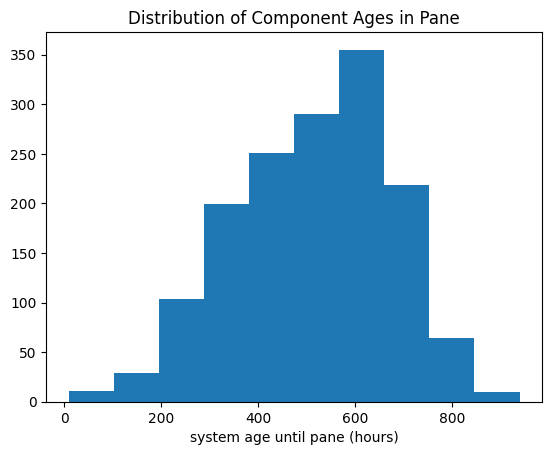

In [28]:
plt.hist(df[df.event_type=="failure"].component_age)
plt.xlabel("system age until pane (hours)")
plt.title("Distribution of Component Ages in Pane")
plt.show()

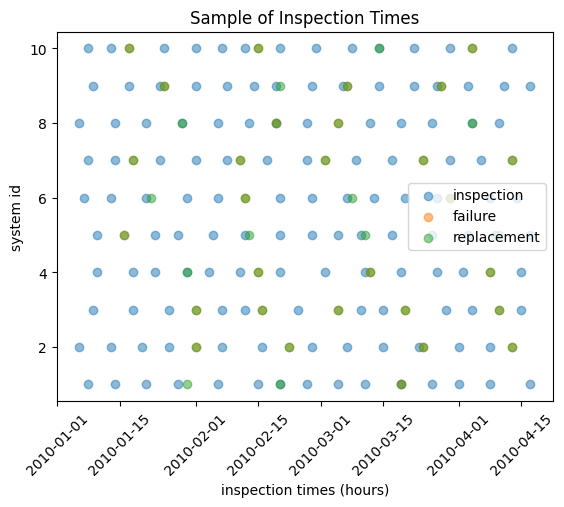

In [29]:
n_events_show = 200
for e_type in df.event_type.unique():
    df_ = df[:n_events_show]
    df_ = df_[df_.event_type == e_type]
    plt.scatter(df_.event_date,
                df_.system_id,
                label=e_type,
                alpha=0.5)

plt.legend()
plt.xlabel("inspection times (hours)")
plt.ylabel("system id")
plt.xticks(rotation=45)
plt.title("Sample of Inspection Times")
plt.show()